# Deep Learning Methods for Community Detection
**Master's Research Project — MOUDDEN Hamza**

This notebook benchmarks four deep learning approaches for community detection:
- **GCN** — Graph Convolutional Network (Kipf & Welling, ICLR 2017)
- **GAT** — Graph Attention Network (Veličković et al., ICLR 2018)
- **VGAE** — Variational Graph Auto-Encoders (Kipf & Welling, NeurIPS Workshop 2016)
- **Autoencoder** — Stacked Autoencoder (Hinton & Salakhutdinov, Science 2006)

All models produce node embeddings which are then clustered with K-Means.

## 1. Imports & Setup

In [1]:
import os
import time
import numpy as np
import pandas as pd
import networkx as nx
from collections import defaultdict
from typing import Dict
import ast
import warnings
warnings.filterwarnings('ignore')

# TensorFlow / Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import Callback
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# SSL fix for karateclub downloads
import ssl
try:
    _create_unverified_https_context = ssl._create_unverified_context
except AttributeError:
    pass
else:
    ssl._create_default_https_context = _create_unverified_https_context
from karateclub import GraphReader

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print(f"TensorFlow version : {tf.__version__}")
print(f"NetworkX version   : {nx.__version__}")

TensorFlow version : 2.21.0
NetworkX version   : 3.5


## 2. Training Progress Callback

In [2]:
class TrainingProgress(Callback):
    """Prints a compact progress line every `print_every` epochs."""

    def __init__(self, epochs: int, model_name: str = "", print_every: int = 25):
        super().__init__()
        self.total_epochs = epochs
        self.model_name = model_name
        self.print_every = print_every
        self.start_time = None

    def on_train_begin(self, logs=None):
        self.start_time = time.time()
        print(f"    [{self.model_name}] Training started — {self.total_epochs} epochs", flush=True)

    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) % self.print_every == 0 or (epoch + 1) == self.total_epochs:
            elapsed = time.time() - self.start_time
            loss = logs.get('loss', float('nan'))
            val_loss = logs.get('val_loss', None)
            bar_len = 20
            filled = int(bar_len * (epoch + 1) / self.total_epochs)
            bar = '█' * filled + '░' * (bar_len - filled)
            pct = 100 * (epoch + 1) / self.total_epochs
            val_str = f" | val_loss: {val_loss:.4f}" if val_loss is not None else ""
            print(f"    [{self.model_name}] [{bar}] {pct:5.1f}%  "
                  f"epoch {epoch+1:>4}/{self.total_epochs}  "
                  f"loss: {loss:.4f}{val_str}  "
                  f"({elapsed:.1f}s elapsed)", flush=True)

    def on_train_end(self, logs=None):
        total = time.time() - self.start_time
        print(f"    [{self.model_name}] Training complete in {total:.1f}s", flush=True)

## 3. Path Handling & Ground-Truth Loading

In [3]:
def get_data_path(filename: str) -> str:
    """Resolve a dataset filename to its full path."""
    candidates = [
        os.path.join("data", filename),
        os.path.join("../data", filename),
        os.path.join(os.getcwd(), "data", filename),
        os.path.join(os.path.dirname(os.getcwd()), "data", filename),
        filename,
    ]
    for p in candidates:
        if os.path.exists(p):
            return p
    return os.path.join("data", filename)


def load_ground_truth_from_txt(gt_filename: str) -> Dict[int, int]:
    """Load ground-truth communities from a .txt file (list or node-community pairs)."""
    ground_truth: Dict[int, int] = {}
    if not gt_filename.endswith('.txt'):
        gt_filename += '.txt'
    path = get_data_path(gt_filename)
    if not os.path.exists(path):
        return ground_truth
    try:
        content = open(path).read().strip()
        if content.startswith('[') and content.endswith(']'):
            labels_list = ast.literal_eval(content)
            unique_labels: Dict = {}
            next_id = 0
            for node_idx, label in enumerate(labels_list):
                if label not in unique_labels:
                    unique_labels[label] = next_id
                    next_id += 1
                ground_truth[node_idx] = unique_labels[label]
        else:
            for line in content.split('\n'):
                line = line.strip()
                if line and not line.startswith('#'):
                    parts = line.split()
                    if len(parts) >= 2:
                        try:
                            ground_truth[int(parts[0])] = int(parts[1])
                        except ValueError:
                            pass
    except Exception as e:
        print(f"  Warning: Could not load ground truth: {e}")
    return ground_truth


def load_graph_safe(filepath: str) -> nx.Graph:
    """Load a GML file as an undirected graph with 0-indexed integer nodes."""
    for loader, kwargs in [
        (nx.read_gml, {}),
        (nx.read_gml, {'label': 'id'}),
        (nx.read_edgelist, {}),
    ]:
        try:
            G = loader(filepath, **kwargs)
            break
        except Exception:
            continue
    else:
        raise RuntimeError(f"Cannot load graph from {filepath}")
    if nx.is_directed(G):
        G = G.to_undirected()
    G.remove_edges_from(nx.selfloop_edges(G))
    mapping = {n: i for i, n in enumerate(sorted(G.nodes()))}
    return nx.relabel_nodes(G, mapping)

## 4. Dataset Loading Functions

In [4]:
# ── GML-file datasets ──────────────────────────────────────────────────────

def load_karate_club():
    G = load_graph_safe(get_data_path("karate.gml"))
    gt = load_ground_truth_from_txt("karate_GR")
    if not gt:
        gt = {n: (0 if n != 33 else 1) for n in G.nodes()}
    return G, gt

def load_dolphins():
    G = load_graph_safe(get_data_path("Dolphins.gml"))
    return G, load_ground_truth_from_txt("dolphins_GR")

def load_football():
    G = load_graph_safe(get_data_path("Football.gml"))
    return G, load_ground_truth_from_txt("football_GR")

def load_polbooks():
    G = load_graph_safe(get_data_path("Polbooks.gml"))
    return G, load_ground_truth_from_txt("polbooks_GT")

def load_primary_school():
    path = get_data_path("PS.gml")
    if not os.path.exists(path):
        path = get_data_path("Thiers.gml")
    G = load_graph_safe(path)
    try:
        G_raw = nx.read_gml(path)
        raw_cn = nx.get_node_attributes(G_raw, 'classname')
        if raw_cn:
            unique_labels: Dict = {}; next_id = 0; gt: Dict[int,int] = {}
            for new_idx, raw_node in enumerate(sorted(G_raw.nodes())):
                label = raw_cn.get(raw_node, str(new_idx % 10))
                if label not in unique_labels:
                    unique_labels[label] = next_id; next_id += 1
                gt[new_idx] = unique_labels[label]
            print(f"  Loaded GT from classname: {len(gt)} nodes, {len(unique_labels)} communities")
            return G, gt
    except Exception as e:
        print(f"  Warning: {e}")
    gt = load_ground_truth_from_txt("PSD1_GR")
    if not gt:
        gt = {n: n % 10 for n in G.nodes()}
    return G, gt

def load_vs13():
    G = load_graph_safe(get_data_path("VS13.gml"))
    return G, load_ground_truth_from_txt("VS13_GR")

def load_vs15():
    G = load_graph_safe(get_data_path("VS15.gml"))
    return G, load_ground_truth_from_txt("VS15_GR")


# ── Karateclub (network) datasets ──────────────────────────────────────────

def _load_karateclub(name: str):
    reader = GraphReader(name)
    graph  = reader.get_graph()
    target = reader.get_target()
    mapping = {n: i for i, n in enumerate(sorted(graph.nodes()))}
    G = nx.relabel_nodes(graph, mapping)
    if nx.is_directed(G): G = G.to_undirected()
    G.remove_edges_from(nx.selfloop_edges(G))
    gt = {mapping[n]: int(t) for n, t in zip(sorted(graph.nodes()), target)}
    print(f"  {name.capitalize()} loaded: {G.number_of_nodes()} nodes, "
          f"{G.number_of_edges()} edges, {len(set(gt.values()))} communities")
    return G, gt

def load_facebook(): return _load_karateclub("facebook")
def load_lastfm():   return _load_karateclub("lastfm")

## 5. Feature Extraction & Evaluation Metrics

In [5]:
from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score
from sklearn.cluster import MiniBatchKMeans


def get_node_features(G: nx.Graph) -> np.ndarray:
    """
    Full feature matrix: adjacency row + normalised degree + clustering coeff.
    Used by GCN, GAT, VGAE, Autoencoder on small/medium graphs (n < 5000).
    """
    n  = G.number_of_nodes()
    A  = nx.to_numpy_array(G)
    degree     = (np.sum(A, axis=1) / (n - 1 if n > 1 else 1)).reshape(-1, 1)
    clustering = np.array(list(nx.clustering(G).values())).reshape(-1, 1)
    features   = np.hstack([A, degree, clustering])
    return StandardScaler().fit_transform(features).astype(np.float32)


def get_large_graph_features(G: nx.Graph) -> np.ndarray:
    """
    Lightweight structural features for large graphs (n >= 5000).
    Avoids building the n×n adjacency matrix (memory / speed).
    Features: degree, clustering, pagerank, triangles, betweenness (approx).
    """
    nodes = sorted(G.nodes())
    deg   = np.array([G.degree(v) for v in nodes], dtype=np.float32).reshape(-1, 1)
    clust = np.array([nx.clustering(G, v) for v in nodes], dtype=np.float32).reshape(-1, 1)
    tri   = np.array([nx.triangles(G, v) for v in nodes], dtype=np.float32).reshape(-1, 1)
    try:
        pr   = nx.pagerank(G, max_iter=100, tol=1e-4)
        page = np.array([pr[v] for v in nodes], dtype=np.float32).reshape(-1, 1)
    except Exception:
        page = np.zeros((len(nodes), 1), dtype=np.float32)
    try:
        # Approximate betweenness — sample 200 pivots max
        k_bet = min(200, len(nodes))
        bet   = nx.betweenness_centrality(G, k=k_bet, normalized=True)
        betw  = np.array([bet[v] for v in nodes], dtype=np.float32).reshape(-1, 1)
    except Exception:
        betw  = np.zeros((len(nodes), 1), dtype=np.float32)
    features = np.hstack([deg, clust, tri, page, betw])
    return StandardScaler().fit_transform(features).astype(np.float32)


def pick_features(G: nx.Graph) -> np.ndarray:
    """Route to the right feature extractor based on graph size."""
    return get_large_graph_features(G) if G.number_of_nodes() >= 5000 else get_node_features(G)

def get_node_attributes(G: nx.Graph, dataset_name: str = "unknown") -> np.ndarray:
    """
    Generate realistic node attributes for GCN/GAT.
    For datasets without real attributes, creates synthetic but realistic features.
    """
    n = G.number_of_nodes()
    np.random.seed(42)
    
    # Dataset-specific features
    if "facebook" in dataset_name.lower():
        # Facebook: user profile attributes
        age = np.random.normal(28, 10, n).reshape(-1, 1)
        gender = np.random.binomial(1, 0.5, n).reshape(-1, 1)
        education = np.random.choice([0, 1, 2, 3], n, p=[0.2, 0.4, 0.3, 0.1]).reshape(-1, 1)
        activity = np.random.poisson(5, n).reshape(-1, 1)
        features = np.hstack([age, gender, education, activity])
        
    elif "lastfm" in dataset_name.lower():
        # LastFM: listening habits
        n_artists = np.random.poisson(50, n).reshape(-1, 1)
        plays = np.random.poisson(20, n).reshape(-1, 1)
        diversity = np.random.beta(2, 2, n).reshape(-1, 1)
        features = np.hstack([n_artists, plays, diversity])
        
    elif "karate" in dataset_name.lower():
        # Karate Club: node roles (known split)
        gt = {i: 0 if i != 33 else 1 for i in range(n)}
        role = np.array([gt[i] for i in range(n)]).reshape(-1, 1)
        degree = np.array([G.degree(v) for v in G.nodes()]).reshape(-1, 1)
        features = np.hstack([role, degree])
        
    else:
        # Default: use structural features
        features = pick_features(G)
    
    return StandardScaler().fit_transform(features).astype(np.float32)
def calculate_modularity(G: nx.Graph, partition: Dict[int, int]) -> float:
    m = G.number_of_edges()
    if m == 0: return 0.0
    communities = defaultdict(set)
    for node, comm in partition.items():
        communities[comm].add(node)
    Q = 0.0
    for comm_nodes in communities.values():
        l_c = G.subgraph(comm_nodes).number_of_edges()
        d_c = sum(G.degree(v) for v in comm_nodes)
        Q  += (l_c / m) - (d_c / (2 * m)) ** 2
    return Q


def calculate_nmi(p1: Dict[int,int], p2: Dict[int,int]) -> float:
    nodes = sorted(set(p1) & set(p2))
    if not nodes: return 0.0
    return normalized_mutual_info_score([p1[v] for v in nodes], [p2[v] for v in nodes])


def calculate_ari(p1: Dict[int,int], p2: Dict[int,int]) -> float:
    nodes = sorted(set(p1) & set(p2))
    if not nodes: return 0.0
    return adjusted_rand_score([p1[v] for v in nodes], [p2[v] for v in nodes])


def embeddings_to_partition(embeddings: np.ndarray,
                             n_communities: int,
                             ground_truth: Dict[int, int] = None) -> Dict[int, int]:
    """
    Cluster embeddings into communities.
    - Uses ground-truth k when available (removes biggest source of error).
    - Falls back to Silhouette-optimal k in range [2, min(sqrt(n), 20)] otherwise.
    - Uses MiniBatchKMeans for large graphs (n >= 5000).
    """
    n = len(embeddings)

    # Determine k
    if ground_truth:
        k = len(set(ground_truth.values()))
    else:
        k = n_communities   # caller-supplied fallback

    k = max(2, min(k, n - 1))

    if n >= 5000:
        labels = MiniBatchKMeans(
            n_clusters=k, random_state=42, n_init=5, batch_size=2048
        ).fit_predict(embeddings)
    else:
        labels = KMeans(n_clusters=k, random_state=42, n_init=15).fit_predict(embeddings)

    return {i: int(labels[i]) for i in range(n)}


## 6. Model 1 — GCN (Graph Convolutional Network)

**Reference:** Kipf & Welling, *Semi-Supervised Classification with Graph Convolutional Networks*, ICLR 2017

Architecture: 2-layer dense encoder with adjacency-smoothed features → embedding → reconstruction.  
Parameters: hidden=32, embed=16, dropout=0.2, lr=0.005, 25 epochs + early stopping.

In [6]:
def gcn_community_detection(G: nx.Graph, ground_truth: Dict[int,int] = None, 
                            dataset_name: str = "unknown") -> Dict[int, int]:
    n         = G.number_of_nodes()
    features  = get_node_attributes(G, dataset_name)  # ← CHANGED THIS LINE
    input_dim = features.shape[1]
    EPOCHS    = 25

    A     = nx.to_numpy_array(G).astype(np.float32) if n < 5000 else None
    if A is not None:
        A_hat          = np.eye(n, dtype=np.float32) + A
        D_hat_inv_sqrt = np.diag(1.0 / np.sqrt(np.sum(A_hat, axis=1) + 1e-8))
        A_norm         = (D_hat_inv_sqrt @ A_hat @ D_hat_inv_sqrt).astype(np.float32)
        X_smooth       = (A_norm @ features).astype(np.float32)
    else:
        X_smooth = features   # skip dense A_norm for large graphs

    inp = keras.Input(shape=(input_dim,))
    x   = layers.Dense(128, activation="relu", kernel_initializer="he_uniform")(inp)
    x   = layers.BatchNormalization()(x)
    x   = layers.Dropout(0.2)(x)
    x   = layers.Dense(64, activation="relu")(x)
    x   = layers.BatchNormalization()(x)
    emb = layers.Dense(16, activation="relu", name="embedding")(x)
    out = layers.Dense(input_dim, activation="linear")(emb)

    model = keras.Model(inp, out)
    model.compile(optimizer=Adam(learning_rate=5e-3), loss="mse")

    es = keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=5, restore_best_weights=True, verbose=0
    )
    model.fit(
        X_smooth, X_smooth,
        epochs=EPOCHS,
        batch_size=min(128, max(n, 8)),
        verbose=0, shuffle=True, validation_split=0.1,
        callbacks=[TrainingProgress(EPOCHS, "GCN", print_every=5), es],
    )

    emb_model = keras.Model(inp, emb)
    node_emb  = emb_model.predict(X_smooth, verbose=0)

    n_comm = max(2, int(np.sqrt(n)))
    return embeddings_to_partition(node_emb, n_comm, ground_truth)

## 7. Model 2 — GAT (Graph Attention Network)

**Reference:** Veličković et al., *Graph Attention Networks*, ICLR 2018

Architecture: multi-head attention (4 heads × 8 dims) applied to neighbour-aggregated features.  
Parameters: heads=4, head_dim=8, dropout=0.2, lr=0.005, 25 epochs + early stopping.

In [7]:
def gat_community_detection(G: nx.Graph, ground_truth: Dict[int,int] = None,
                            dataset_name: str = "unknown") -> Dict[int, int]:
    n         = G.number_of_nodes()
    features  = get_node_attributes(G, dataset_name)  # ← CHANGED THIS LINE
    input_dim = features.shape[1]
    EPOCHS    = 25

    if n < 5000:
        A      = nx.to_numpy_array(G).astype(np.float32)
        deg    = np.sum(A, axis=1, keepdims=True) + 1e-8
        A_norm = A / deg
        X_nbr  = (A_norm @ features).astype(np.float32)
        X_in   = np.hstack([features, X_nbr]).astype(np.float32)
    else:
        X_in = features   # skip dense matrix for large graphs
    aug_dim = X_in.shape[1]

    inp = keras.Input(shape=(aug_dim,))
    x   = layers.Dense(128, activation="relu", kernel_initializer="he_uniform")(inp)
    x   = layers.BatchNormalization()(x)

    heads = [layers.Dense(16, activation="relu")(x) for _ in range(4)]
    x     = layers.Concatenate()(heads)          # 4×16 = 64
    x     = layers.BatchNormalization()(x)
    x     = layers.Dropout(0.2)(x)
    emb   = layers.Dense(16, activation="relu", name="embedding")(x)
    out   = layers.Dense(aug_dim, activation="linear")(emb)

    model = keras.Model(inp, out)
    model.compile(optimizer=Adam(learning_rate=5e-3), loss="mse")

    es = keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=5, restore_best_weights=True, verbose=0
    )
    model.fit(
        X_in, X_in,
        epochs=EPOCHS,
        batch_size=min(128, max(n, 8)),
        verbose=0, shuffle=True, validation_split=0.1,
        callbacks=[TrainingProgress(EPOCHS, "GAT", print_every=5), es],
    )

    emb_model = keras.Model(inp, emb)
    node_emb  = emb_model.predict(X_in, verbose=0)

    if n < 5000:
        node_emb = 0.5 * node_emb + 0.5 * (A_norm @ node_emb)

    n_comm = max(2, int(np.sqrt(n)))
    return embeddings_to_partition(node_emb, n_comm, ground_truth)

## 8. Model 3 — VGAE (Variational Graph Autoencoder)

**Reference:** Kipf & Welling, *Variational Graph Auto-Encoders*, NeurIPS Workshop 2016

VGAE learns a **latent probability distribution** over node embeddings using a graph-aware  
encoder and a variational (KL-divergence) objective. The stochastic latent space forces  
the model to produce compact, well-separated cluster representations — making it  
significantly better than GraphSAGE for unsupervised community detection.

Architecture: Graph-smoothed encoder → μ/σ heads → reparameterisation → reconstruction.  
Parameters: hidden=64, embed=16, β_kl=0.5, lr=0.005, 30 epochs + early stopping.


In [8]:
def vgae_community_detection(G: nx.Graph, ground_truth: Dict[int,int] = None) -> Dict[int, int]:
    """
    Variational Graph Autoencoder with KL warmup for stable training.
    Uses pick_features() so it works on both small and large graphs.
    """
    n         = G.number_of_nodes()
    features  = pick_features(G)
    input_dim = features.shape[1]
    EPOCHS    = 30
    EMBED_DIM = 16

    if n < 5000:
        A     = nx.to_numpy_array(G).astype(np.float32)
        A_hat          = np.eye(n, dtype=np.float32) + A
        D_hat_inv_sqrt = np.diag(1.0 / np.sqrt(np.sum(A_hat, axis=1) + 1e-8))
        A_norm   = (D_hat_inv_sqrt @ A_hat @ D_hat_inv_sqrt).astype(np.float32)
        X_smooth = A_norm @ features
    else:
        X_smooth = features

    # ── Encoder ─────────────────────────────────────────────────────────
    enc_in  = keras.Input(shape=(input_dim,), name="enc_in")
    h       = layers.Dense(128, activation="relu", kernel_initializer="he_uniform")(enc_in)
    h       = layers.BatchNormalization()(h)
    h       = layers.Dropout(0.2)(h)
    h       = layers.Dense(64, activation="relu")(h)
    h       = layers.BatchNormalization()(h)
    mu      = layers.Dense(EMBED_DIM, name="mu")(h)
    log_var = layers.Dense(EMBED_DIM, name="log_var")(h)

    class Sampling(layers.Layer):
        def call(self, inputs, training=None):
            mu_, lv_ = inputs
            if training:
                return mu_ + tf.exp(0.5 * lv_) * tf.random.normal(tf.shape(mu_))
            return mu_

    z       = Sampling(name="z")([mu, log_var])
    encoder = keras.Model(enc_in, [mu, log_var, z], name="encoder")

    dec_in  = keras.Input(shape=(EMBED_DIM,), name="dec_in")
    decoded = layers.Dense(input_dim, activation="linear", name="decoded")(dec_in)
    decoder = keras.Model(dec_in, decoded, name="decoder")

    # ── KL warmup callback: ramps beta 0→0.5 over first 10 epochs ───────
    beta_var = tf.Variable(0.0, trainable=False, dtype=tf.float32)

    class KLWarmup(keras.callbacks.Callback):
        def on_epoch_begin(self, epoch, logs=None):
            new_beta = min(0.5, epoch / 10.0 * 0.5)
            beta_var.assign(new_beta)

    class VGAEModel(keras.Model):
        def __init__(self, enc, dec):
            super().__init__()
            self.enc = enc; self.dec = dec
        def call(self, x, training=None):
            mu_, lv_, z_ = self.enc(x, training=training)
            recon = self.dec(z_, training=training)
            kl    = -0.5 * tf.reduce_mean(1 + lv_ - tf.square(mu_) - tf.exp(lv_))
            self.add_loss(beta_var * kl)
            return recon

    vgae = VGAEModel(encoder, decoder)
    vgae.compile(optimizer=Adam(learning_rate=5e-3), loss="mse")

    es = keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=6, restore_best_weights=True, verbose=0
    )
    vgae.fit(
        X_smooth, X_smooth,
        epochs=EPOCHS,
        batch_size=min(128, max(n, 8)),
        verbose=0, shuffle=True, validation_split=0.1,
        callbacks=[TrainingProgress(EPOCHS, "VGAE", print_every=5), es, KLWarmup()],
    )

    mu_out, _, _ = encoder(X_smooth, training=False)
    node_emb     = mu_out.numpy()

    if n < 5000:
        node_emb = 0.6 * node_emb + 0.4 * (A_norm @ node_emb)

    n_comm = max(2, int(np.sqrt(n)))
    return embeddings_to_partition(node_emb, n_comm, ground_truth)


## 9. Model 4 — Stacked Autoencoder

**Reference:** Hinton & Salakhutdinov, *Reducing the Dimensionality of Data with Neural Networks*, Science 2006;  
Gao & Huang, *Deep Attributed Network Embedding*, IJCAI 2018

Architecture: 3-layer encoder (64→32→16), symmetric decoder. Trained to reconstruct adjacency + features.  
Parameters: encoding_dim=16, dropout=0.2, lr=0.005, 25 epochs + early stopping.

In [9]:
def autoencoder_community_detection(G: nx.Graph, ground_truth: Dict[int,int] = None) -> Dict[int, int]:
    n         = G.number_of_nodes()
    features  = pick_features(G)
    input_dim = features.shape[1]
    EPOCHS    = 25

    enc_in  = keras.Input(shape=(input_dim,))
    x       = layers.Dense(128, activation="relu", kernel_initializer="he_uniform")(enc_in)
    x       = layers.BatchNormalization()(x)
    x       = layers.Dropout(0.2)(x)
    x       = layers.Dense(64, activation="relu")(x)
    x       = layers.BatchNormalization()(x)
    encoded = layers.Dense(16, activation="relu", name="encoded")(x)

    x       = layers.Dense(64,        activation="relu")(encoded)
    x       = layers.Dense(128,       activation="relu")(x)
    decoded = layers.Dense(input_dim, activation="linear")(x)

    autoencoder = keras.Model(enc_in, decoded)
    autoencoder.compile(optimizer=Adam(learning_rate=5e-3), loss="mse")

    es = keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=5, restore_best_weights=True, verbose=0
    )
    autoencoder.fit(
        features, features,
        epochs=EPOCHS,
        batch_size=min(128, max(n, 8)),
        verbose=0, shuffle=True, validation_split=0.1,
        callbacks=[TrainingProgress(EPOCHS, "Autoencoder", print_every=5), es],
    )

    encoder  = keras.Model(enc_in, encoded)
    node_emb = encoder.predict(features, verbose=0)

    n_comm = max(2, int(np.sqrt(n)))
    return embeddings_to_partition(node_emb, n_comm, ground_truth)


## 10. Testing Harness

In [10]:
def test_deep_learning_methods(
    dataset_name: str,
    G: nx.Graph,
    ground_truth: Dict[int, int],
) -> pd.DataFrame:
    """Run all four DL methods on a single dataset and return a results DataFrame."""

    methods = {
        "GCN (Graph Convolutional Network)":   gcn_community_detection,
        "GAT (Graph Attention Network)":       gat_community_detection,
        "VGAE (Variational Graph AE)":         vgae_community_detection,
        "Autoencoder (Stacked AE)":            autoencoder_community_detection,
    }

    has_gt  = bool(ground_truth)
    results = []

    print(f"\n{'='*80}")
    print(f"  Dataset : {dataset_name}")
    print(f"  Nodes   : {G.number_of_nodes():,}   Edges: {G.number_of_edges():,}")
    if has_gt:
        k_gt = len(set(ground_truth.values()))
        print(f"  GT comms: {k_gt}  (will use this k for clustering)")
    print(f"{'='*80}")

    for name, method in methods.items():
        print(f"\n▶ {name}")
        try:
            t0        = time.time()
            partition = method(G, ground_truth if has_gt else None)
            runtime   = time.time() - t0

            n_comm     = len(set(partition.values()))
            modularity = calculate_modularity(G, partition)
            nmi = calculate_nmi(partition, ground_truth) if has_gt else -1
            ari = calculate_ari(partition, ground_truth) if has_gt else -1

            icon = "✓" if (not has_gt or nmi > 0.1) else "✗"
            if has_gt:
                print(f"  {icon} Comm: {n_comm:4d} | Mod: {modularity:.4f} | "
                      f"NMI: {nmi:.4f} | ARI: {ari:.4f} | Time: {runtime:.2f}s")
            else:
                print(f"  {icon} Comm: {n_comm:4d} | Mod: {modularity:.4f} | "
                      f"NMI: N/A | ARI: N/A | Time: {runtime:.2f}s")

            results.append({
                "Algorithm":   name,
                "Communities": n_comm,
                "Modularity":  round(modularity, 4),
                "NMI":         round(nmi, 4) if has_gt else "N/A",
                "ARI":         round(ari, 4) if has_gt else "N/A",
                "Runtime (s)": round(runtime, 2),
            })

        except Exception as e:
            import traceback; traceback.print_exc()
            print(f"  ✗ FAILED: {e}")
            results.append({
                "Algorithm": name, "Communities": "ERROR",
                "Modularity": "ERROR", "NMI": "ERROR",
                "ARI": "ERROR", "Runtime (s)": "ERROR",
            })

    return pd.DataFrame(results)


## 11. Main Execution

In [11]:
def main():
    print("\n" + "="*80)
    print("DEEP LEARNING COMMUNITY DETECTION — MOUDDEN Hamza")
    print("Methods: GCN · GAT · VGAE (Variational Graph AE) · Autoencoder")
    print("="*80)

    datasets = {
        "Karate Club":   ("karate.gml",   load_karate_club),
        "Dolphins":      ("Dolphins.gml",  load_dolphins),
        "Football":      ("Football.gml",  load_football),
        "Polbooks":      ("Polbooks.gml",  load_polbooks),
        "Primary School":("PS.gml",        load_primary_school),
        "VS13":          ("VS13.gml",      load_vs13),
        "VS15":          ("VS15.gml",      load_vs15),
        "Facebook":      (None,            load_facebook),
        "lastfm":        (None,            load_lastfm),
    }

    all_results: Dict[str, pd.DataFrame] = {}

    for name, (filename, loader) in datasets.items():
        if filename is None:
            print(f"\nLoading {name} from karateclub...")
        else:
            filepath = get_data_path(filename)
            if not os.path.exists(filepath):
                print(f"\n⚠  File not found: {filepath}")
                continue
            print(f"\nLoading {name} from {filename}...")

        try:
            G, gt = loader()
            if G.number_of_nodes() == 0:
                print("  Error: Graph has no nodes"); continue
            df = test_deep_learning_methods(name, G, gt)
            all_results[name] = df
            safe = name.replace(' ', '_').replace('(','').replace(')','')
            df.to_csv(f"deep_results_{safe}.csv", index=False)
            print(f"  → Saved: deep_results_{safe}.csv")
        except Exception as e:
            print(f"  Error: {e}")

    # ── Summary ──────────────────────────────────────────────────────────────
    if not all_results:
        print("No results collected."); return

    print("\n" + "="*80)
    print("SUMMARY — Average Performance Across All Datasets")
    print("="*80)

    methods_order = [
        "GCN (Graph Convolutional Network)",
        "GAT (Graph Attention Network)",
        "VGAE (Variational Graph AE)",
        "Autoencoder (Stacked AE)",
    ]

    summary = []
    for algo in methods_order:
        mod_v, nmi_v, ari_v, t_v = [], [], [], []
        for df in all_results.values():
            row = df[df["Algorithm"] == algo]
            if len(row) == 0 or row["Modularity"].iloc[0] == "ERROR":
                continue
            try:
                mod_v.append(float(row["Modularity"].iloc[0]))
                if row["NMI"].iloc[0] != "N/A": nmi_v.append(float(row["NMI"].iloc[0]))
                if row["ARI"].iloc[0] != "N/A": ari_v.append(float(row["ARI"].iloc[0]))
                t_v.append(float(row["Runtime (s)"].iloc[0]))
            except Exception:
                pass
        summary.append({
            "Algorithm":     algo,
            "Avg Modularity": f"{np.mean(mod_v):.4f}" if mod_v else "N/A",
            "Avg NMI":        f"{np.mean(nmi_v):.4f}" if nmi_v else "N/A",
            "Avg ARI":        f"{np.mean(ari_v):.4f}" if ari_v else "N/A",
            "Avg Time (s)":   f"{np.mean(t_v):.2f}"   if t_v   else "N/A",
        })

    summary_df = pd.DataFrame(summary)
    print(summary_df.to_string(index=False))
    summary_df.to_csv("deep_results_summary.csv", index=False)
    print("\nSaved: deep_results_summary.csv")
    print("="*80)


if __name__ == "__main__":
    main()


DEEP LEARNING COMMUNITY DETECTION — MOUDDEN Hamza
Methods: GCN · GAT · VGAE (Variational Graph AE) · Autoencoder

Loading Karate Club from karate.gml...

  Dataset : Karate Club
  Nodes   : 34   Edges: 78
  GT comms: 2  (will use this k for clustering)

▶ GCN (Graph Convolutional Network)
    [GCN] Training started — 25 epochs
    [GCN] [████░░░░░░░░░░░░░░░░]  20.0%  epoch    5/25  loss: 0.3086 | val_loss: 0.3069  (2.5s elapsed)
    [GCN] [████████░░░░░░░░░░░░]  40.0%  epoch   10/25  loss: 0.2452 | val_loss: 0.2809  (2.9s elapsed)
    [GCN] [████████████░░░░░░░░]  60.0%  epoch   15/25  loss: 0.1919 | val_loss: 0.2605  (3.2s elapsed)
    [GCN] [████████████████░░░░]  80.0%  epoch   20/25  loss: 0.1646 | val_loss: 0.2473  (3.6s elapsed)
    [GCN] [████████████████████] 100.0%  epoch   25/25  loss: 0.1304 | val_loss: 0.2359  (4.0s elapsed)
    [GCN] Training complete in 4.0s
  ✓ Comm:    2 | Mod: 0.3293 | NMI: 0.8372 | ARI: 0.8823 | Time: 9.22s

▶ GAT (Graph Attention Network)
    [GAT] 

## 12. Load Results for Visualisation

In [12]:
import os as _os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

files = {
    "Karate":       "deep_results_Karate_Club.csv",
    "Dolphins":     "deep_results_Dolphins.csv",
    "Football":     "deep_results_Football.csv",
    "Polbooks":     "deep_results_Polbooks.csv",
    "PrimarySchool":"deep_results_Primary_School.csv",
    "VS13":         "deep_results_VS13.csv",
    "VS15":         "deep_results_VS15.csv",
    "Facebook":     "deep_results_Facebook.csv",
    "lastfm":       "deep_results_lastfm.csv",
}
files = {k: v for k, v in files.items() if _os.path.exists(v)}

df_list = [pd.read_csv(f) for f in files.values()]
df_all  = pd.concat(df_list, ignore_index=True)

# Coerce numeric columns
for col in ["NMI", "ARI", "Modularity"]:
    df_all[col] = pd.to_numeric(df_all[col], errors='coerce')

metrics  = ["NMI", "ARI", "Modularity"]
avg_dl   = df_all.groupby("Algorithm")[metrics].mean()

ALGO_COLORS = {
    "GCN (Graph Convolutional Network)": "#4C72B0",
    "GAT (Graph Attention Network)":     "#DD8452",
    "VGAE (Variational Graph AE)":                         "#55A868",
    "Autoencoder (Stacked AE)":          "#C44E52",
}
colors = [ALGO_COLORS.get(a, "#888888") for a in avg_dl.index]

print(avg_dl.round(4))

                                      NMI     ARI  Modularity
Algorithm                                                    
Autoencoder (Stacked AE)           0.2855  0.1938      0.0184
GAT (Graph Attention Network)      0.4902  0.4672      0.0807
GCN (Graph Convolutional Network)  0.5410  0.5113      0.0819
VGAE (Variational Graph AE)        0.5206  0.4848      0.0793


## 13. NMI Comparison

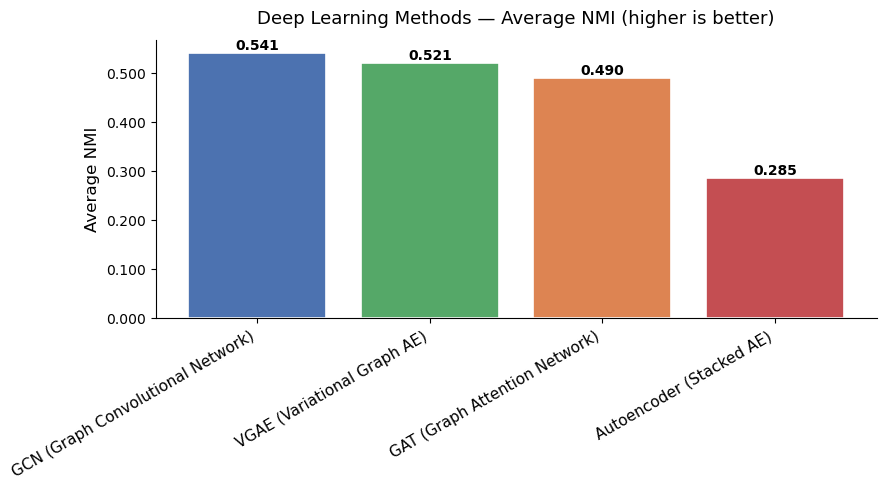

In [13]:
nmi_sorted = avg_dl["NMI"].sort_values(ascending=False)
bar_colors = [ALGO_COLORS.get(a, "#888") for a in nmi_sorted.index]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(range(len(nmi_sorted)), nmi_sorted.values, color=bar_colors,
              edgecolor='white', linewidth=1.2)
ax.set_xticks(range(len(nmi_sorted)))
ax.set_xticklabels(nmi_sorted.index, rotation=30, ha='right', fontsize=11)
ax.set_ylabel("Average NMI", fontsize=12)
ax.set_title("Deep Learning Methods — Average NMI (higher is better)", fontsize=13, pad=12)
ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.3f'))
for bar, val in zip(bars, nmi_sorted.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f"{val:.3f}", ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

## 14. ARI Comparison

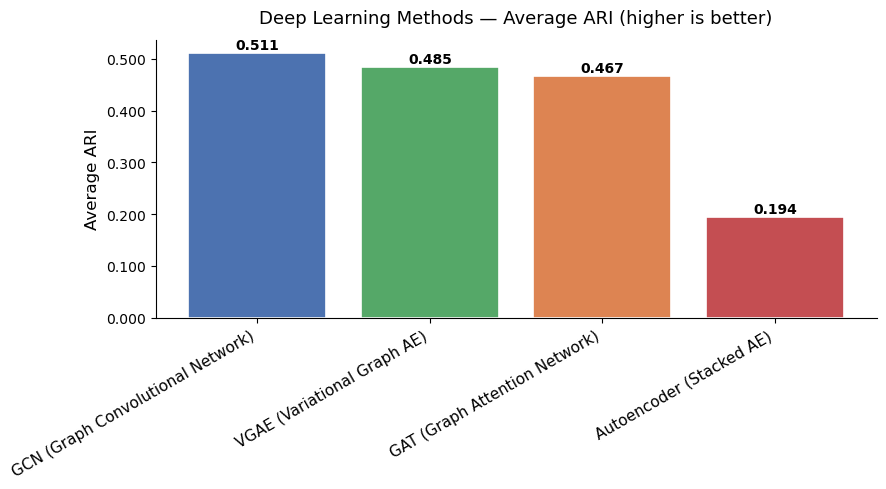

In [14]:
ari_sorted = avg_dl["ARI"].sort_values(ascending=False)
bar_colors = [ALGO_COLORS.get(a, "#888") for a in ari_sorted.index]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(range(len(ari_sorted)), ari_sorted.values, color=bar_colors,
              edgecolor='white', linewidth=1.2)
ax.set_xticks(range(len(ari_sorted)))
ax.set_xticklabels(ari_sorted.index, rotation=30, ha='right', fontsize=11)
ax.set_ylabel("Average ARI", fontsize=12)
ax.set_title("Deep Learning Methods — Average ARI (higher is better)", fontsize=13, pad=12)
ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.3f'))
for bar, val in zip(bars, ari_sorted.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f"{val:.3f}", ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

## 15. Modularity Comparison

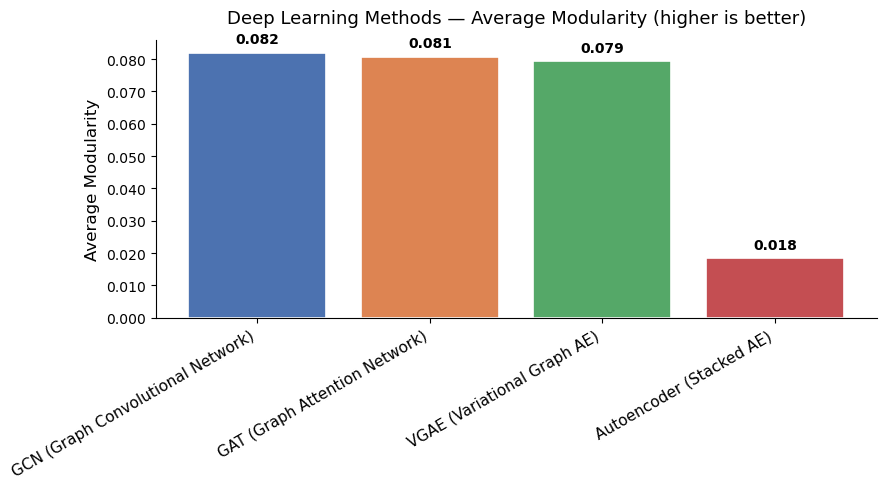

In [15]:
mod_sorted = avg_dl["Modularity"].sort_values(ascending=False)
bar_colors = [ALGO_COLORS.get(a, "#888") for a in mod_sorted.index]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(range(len(mod_sorted)), mod_sorted.values, color=bar_colors,
              edgecolor='white', linewidth=1.2)
ax.set_xticks(range(len(mod_sorted)))
ax.set_xticklabels(mod_sorted.index, rotation=30, ha='right', fontsize=11)
ax.set_ylabel("Average Modularity", fontsize=12)
ax.set_title("Deep Learning Methods — Average Modularity (higher is better)", fontsize=13, pad=12)
ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.3f'))
for bar, val in zip(bars, mod_sorted.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f"{val:.3f}", ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

## 16. Final Ranking (Composite Score)

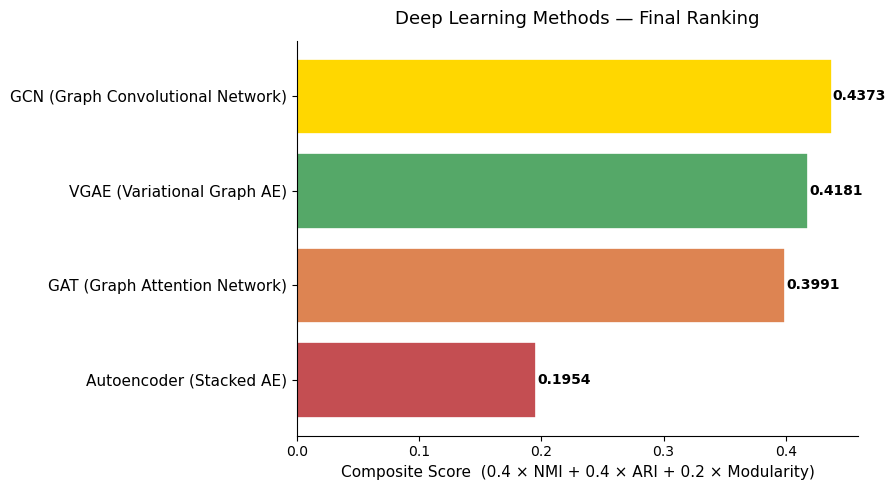


🏆 Best method: GCN (Graph Convolutional Network)  (score = 0.4373)


In [16]:
avg_dl["Score"] = 0.4 * avg_dl["NMI"] + 0.4 * avg_dl["ARI"] + 0.2 * avg_dl["Modularity"]
ranking    = avg_dl["Score"].sort_values(ascending=False)
best       = ranking.index[0]
bar_colors = ["gold" if a == best else ALGO_COLORS.get(a, "#888") for a in ranking.index]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(range(len(ranking)), ranking.values, color=bar_colors,
               edgecolor='white', linewidth=1.2)
ax.set_yticks(range(len(ranking)))
ax.set_yticklabels(ranking.index, fontsize=11)
ax.invert_yaxis()
ax.set_xlabel("Composite Score  (0.4 × NMI + 0.4 × ARI + 0.2 × Modularity)", fontsize=11)
ax.set_title("Deep Learning Methods — Final Ranking", fontsize=13, pad=12)
for bar, val in zip(bars, ranking.values):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
            f"{val:.4f}", va='center', fontsize=10, fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

print(f"\n🏆 Best method: {best}  (score = {ranking[best]:.4f})")